# Optimization for Function 5

You’re tasked with optimising a four-variable black-box function that represents the yield of a chemical process in a factory. The function is typically unimodal, with a single peak where yield is maximised. 

Your goal is to find the optimal combination of chemical inputs that delivers the highest possible yield, using systematic exploration and optimisation methods.

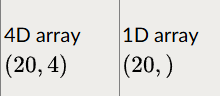

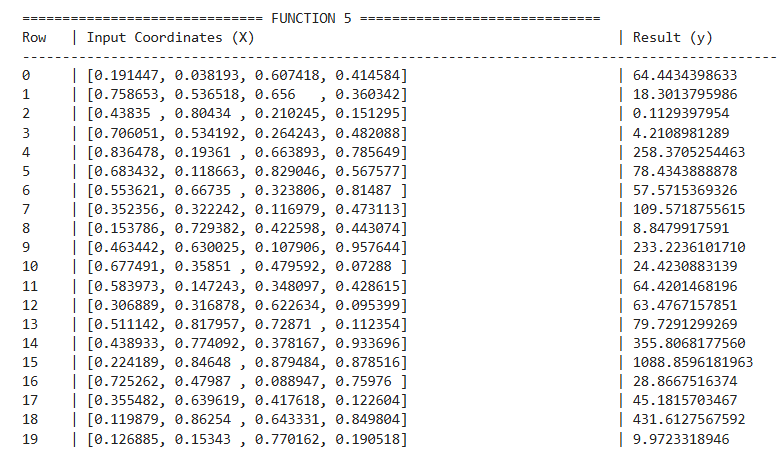

Goal: Maximise the black-box function using Bayesian Optimization.

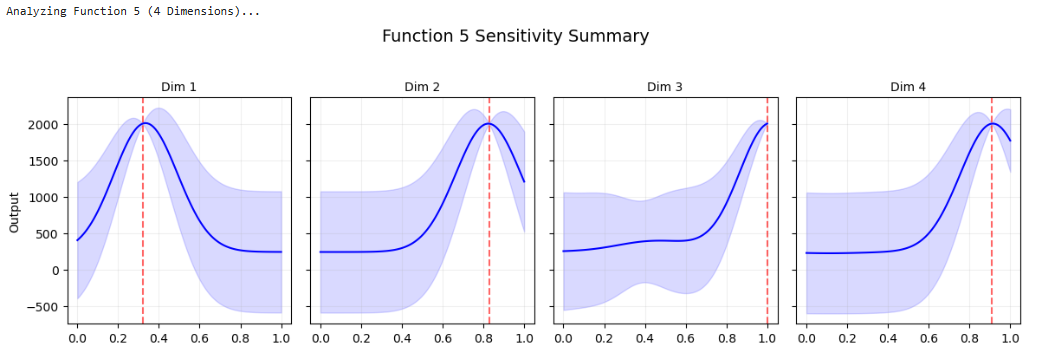

In [1]:
import numpy as np
import os
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C

# 1. Load Data
fn_num = '5'
path = f'../capstone_data/initial_data/function_{fn_num}/'
X = np.load(os.path.join(path, 'initial_inputs.npy'))
y = np.load(os.path.join(path, 'initial_outputs.npy'))

print(f"--- Function {fn_num} Loaded ---")
print(f"Current Max Yield: {np.max(y):.6f}")

# 2. Setup GP
# For a unimodal function, a smooth RBF kernel is perfect
kernel = C(1.0, (1e-3, 1e3)) * RBF(0.1, (1e-2, 1e2))
gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-6, normalize_y=True)
gp.fit(X, y)

# 3. 4D Grid - Randomized Sampling
random_points = np.random.uniform(0, 1, (200000, 4))
mu, sigma = gp.predict(random_points, return_std=True)

# 4. UCB Acquisition - Low Kappa for Exploitation (Unimodal Peak)
kappa = 1.0  # We want to zoom in on that single peak
ucb_score = mu + (kappa * sigma)
best_idx = np.argmax(ucb_score)
suggestion = random_points[best_idx]

print(f"\n--- WEEK 5 RECOMMENDATION (Exploitation) ---")
print(f"Input 1: {suggestion[0]:.6f}")
print(f"Input 2: {suggestion[1]:.6f}")
print(f"Input 3: {suggestion[2]:.6f}")
print(f"Input 4: {suggestion[3]:.6f}")
print(f"Predicted Yield at summit: {mu[best_idx]:.6f}")

--- Function 5 Loaded ---
Current Max Yield: 1088.859618

--- WEEK 5 RECOMMENDATION (Exploitation) ---
Input 1: 0.320145
Input 2: 0.827134
Input 3: 0.999109
Input 4: 0.909586
Predicted Yield at summit: 1160.911026


Here we are Optimizing the yield of a chemical process. This is a single peak model which means we can opt for aggressive exploitation. Hence we will use the Upper Confidence Bound (UCB) but with a Low Kappa.

previous best ~1088 (Row 15).
Predicted 1160

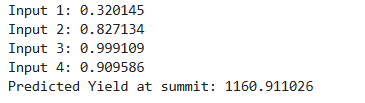

Week 2
----------

In Function 5 (the unimodal chemical yield), prediction was roughly 1160, but output received was 2002.01. This could be the main mountain. Considering it is steeper than predicted, greedy exploitation is right approach. Hence we would use UCB with low kappa 0.1. We would keep alpha to very very low as picture is not noisy.

In [2]:
import numpy as np
import os
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from scipy.stats import qmc

# 1. Load Updated Data (ensure 2002.01 is in there!)
fn_num = '5'
path = f'../capstone_data/initial_data/function_{fn_num}/'
X = np.load(os.path.join(path, 'initial_inputs.npy'))
y = np.load(os.path.join(path, 'initial_outputs.npy'))

# 2. Setup GP (Strict/Low Alpha for precise summiting)
kernel = C(1.0, (1e-3, 1e3)) * RBF(0.1, (1e-2, 1e2))
gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-10, normalize_y=True)
gp.fit(X, y)

# 3. 4D Latin Hypercube Sampling (100k points)
sampler = qmc.LatinHypercube(d=4)
sample_points = sampler.random(n=100000)

# 4. Acquisition (UCB with very low Kappa for Exploitation)
mu, sigma = gp.predict(sample_points, return_std=True)
kappa = 0.1
ucb_score = mu + (kappa * sigma)
best_idx = np.argmax(ucb_score)
suggestion = sample_points[best_idx]

print(f"--- Function 5 Module 13 Suggestion ---")
print(f"Next Query: {'-'.join([f'{val:.6f}' for val in suggestion])}")
print(f"Predicted Score: {mu[best_idx]:.6f}")
print(f"Uncertainty (Sigma): {sigma[best_idx]:.6f}")

--- Function 5 Module 13 Suggestion ---
Next Query: 0.315692-0.795260-0.998721-0.939135
Predicted Score: 1949.069991
Uncertainty (Sigma): 112.753878


SENSITIVITY ANALYSIS
----------------------
---------------------------
---------------------------


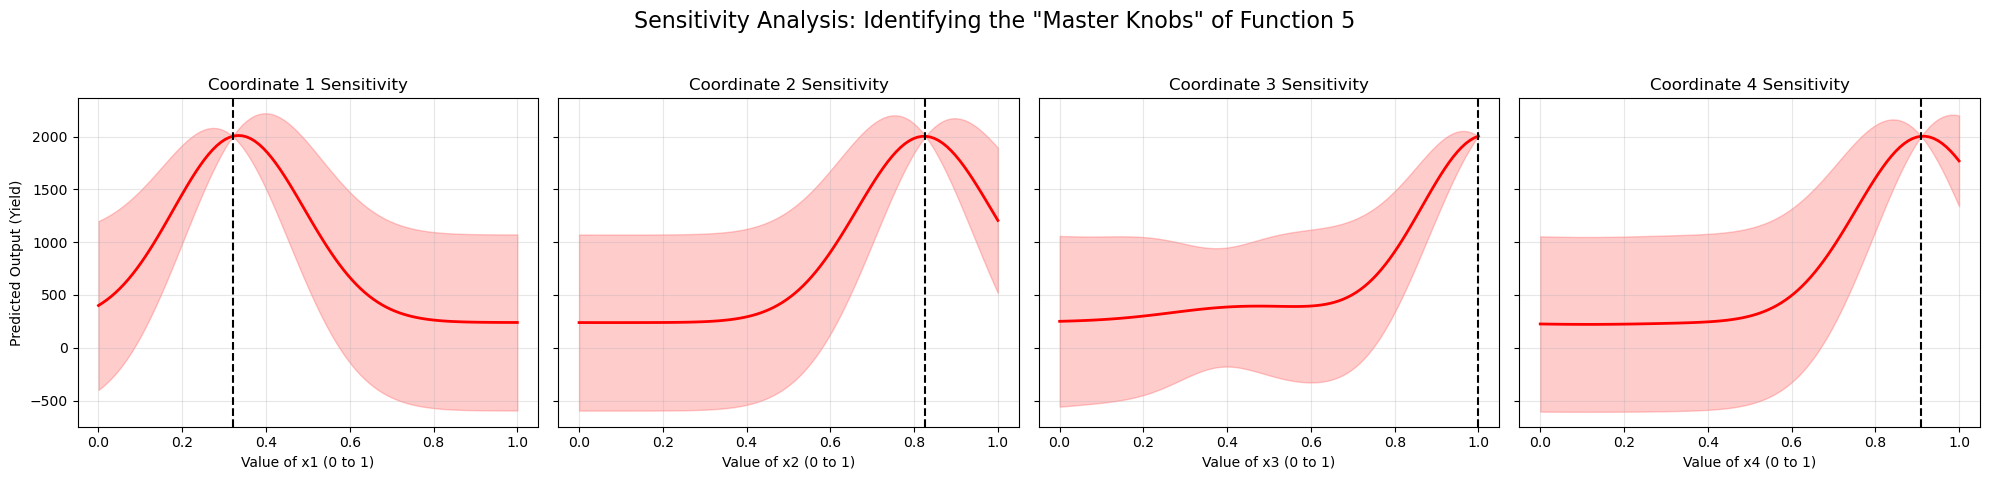

In [6]:
import numpy as np
import os
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C

# 1. Load your current data (Function 5)
fn_num = '5'
path = f'../capstone_data/initial_data/function_{fn_num}/'
X = np.load(os.path.join(path, 'initial_inputs.npy'))
y = np.load(os.path.join(path, 'initial_outputs.npy'))

# 2. Setup GP with low alpha (high trust)
# Using the same kernel as your main scripts for consistency
kernel = C(1.0, (1e-3, 1e3)) * RBF(0.1, (1e-2, 1e2))
gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-10, normalize_y=True)
gp.fit(X, y)

# 3. Identify the best point found so far (the 2002.01 point)
best_idx = np.argmax(y)
best_x = X[best_idx]

# 4. Create a figure with 4 subplots (one for each dimension)
fig, axes = plt.subplots(1, 4, figsize=(20, 5), sharey=True)

for dim in range(4):
    ax = axes[dim]
    sweep_values = np.linspace(0, 1, 100)
    
    # Create test points: All dimensions fixed at best_x except the current 'dim'
    test_points = np.tile(best_x, (100, 1))
    test_points[:, dim] = sweep_values
    
    # Predict Mean and Uncertainty (Sigma)
    mu, sigma = gp.predict(test_points, return_std=True)
    
    # Plotting the individual effect of this dimension
    ax.plot(sweep_values, mu, color='red', lw=2, label='Predicted Yield')
    ax.fill_between(sweep_values, mu - 1.96*sigma, mu + 1.96*sigma, alpha=0.2, color='red', label='95% Confidence')
    ax.axvline(best_x[dim], color='black', linestyle='--', label='Current Best')
    
    ax.set_title(f'Coordinate {dim+1} Sensitivity')
    ax.set_xlabel(f'Value of x{dim+1} (0 to 1)')
    if dim == 0:
        ax.set_ylabel('Predicted Output (Yield)')
    ax.grid(True, alpha=0.3)

plt.suptitle('Sensitivity Analysis: Identifying the "Master Knobs" of Function 5', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig('function_5_full_sensitivity.png')
plt.show()

Week 3
-------------

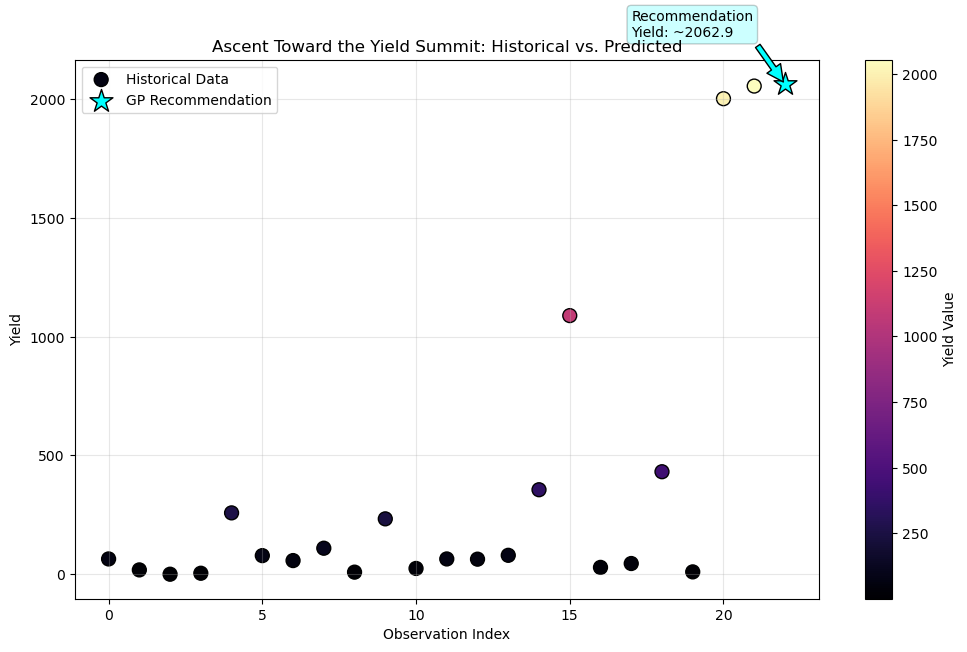

--- Key Yield Values ---
Initial Best: Input [0.22418902 0.84648049 0.87948418 0.87851568], Yield 1088.859618
W1 (2002):    Input [0.320145 0.827134 0.999109 0.909586], Yield 2002.014656
W2 (2055):    Input [0.315692 0.79526  0.998721 0.939135], Yield 2055.173023
Predicted:    Input [0.3198962  0.80286499 1.         0.93245498], Predicted Yield 2062.935299


In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern
from scipy.optimize import minimize

# 1. Load Data
X = np.load('../capstone_data/initial_data/function_5/initial_inputs.npy')
y = np.load('../capstone_data/initial_data/function_5/initial_outputs.npy')

# 2. Identify Key Historical Points
# Initial Best is the maximum yield from the first 20 observations (Index 0-19)
base_y = y[:-2]
initial_best_idx = np.argmax(base_y)
initial_best_input = X[initial_best_idx]
initial_best_yield = y[initial_best_idx]

# W1 and W2 are the last two points (Index 20 and 21)
w1_input, w1_yield = X[-2], y[-2]
w2_input, w2_yield = X[-1], y[-1]

# 3. Fit Gaussian Process (Matern kernel for sharp peaks)
kernel = Matern(length_scale=1.0, nu=1.5)
gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10, random_state=42)
gp.fit(X, y)

# 4. Greedy Exploitation to find the Recommendation
best_idx = np.argmax(y)
res = minimize(lambda x: -gp.predict(x.reshape(1, -1))[0], 
               X[best_idx], 
               bounds=[(0, 1)]*4)
next_x = res.x
predicted_y = gp.predict(next_x.reshape(1, -1))[0]

# 5. Visualization
plt.figure(figsize=(12, 7))
indices = np.arange(len(y))

# Scatter plot using magma colormap to show the ascent
sc = plt.scatter(indices, y, c=y, cmap='magma', s=100, edgecolors='k', label='Historical Data')
plt.colorbar(sc, label='Yield Value')

# Highlight Recommendation
plt.scatter(len(y), predicted_y, color='cyan', marker='*', s=300, 
            edgecolors='black', label='GP Recommendation')

# Annotations
plt.annotate(f'Recommendation\nYield: ~{predicted_y:.1f}', 
             xy=(len(y), predicted_y), xytext=(len(y)-5, predicted_y+200),
             arrowprops=dict(facecolor='cyan', shrink=0.05),
             bbox=dict(boxstyle="round,pad=0.3", fc="cyan", alpha=0.2))

plt.title("Ascent Toward the Yield Summit: Historical vs. Predicted")
plt.xlabel("Observation Index")
plt.ylabel("Yield")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# 6. Print the requested values
print("--- Key Yield Values ---")
print(f"Initial Best: Input {initial_best_input}, Yield {initial_best_yield:.6f}")
print(f"W1 (2002):    Input {w1_input}, Yield {w1_yield:.6f}")
print(f"W2 (2055):    Input {w2_input}, Yield {w2_yield:.6f}")
print(f"Predicted:    Input {next_x}, Predicted Yield {predicted_y:.6f}")

Week 5
-----------

The Sobol indices highlight $X_4$ ($0.20$) and $X_3$ ($0.10$) as the primary drivers of yield. Your strategy to push these values toward $1.0$

Week 3 results show that  Given $X_4$ has the highest sensitivity, this confirms that the peak is extremely sensitive to even small changes in $X_4$.

Since the function is unimodal and you are already in the "99th percentile" of yield, the strategy should shift from Greedy Exploitation to Local Refinement (Micro-Exploitation):

Primary Adjustment: Test a value of $X_4$ slightly higher than $W2$, such as $0.95$, while holding $X_3$ just below the boundary (e.g., $0.99$) to see if the $1.0$ boundary for $X_3$ is creating a constraint.Goal: Find the exact "sharp peak" coordinates to push past the $2055$ mark.

       Point       X1       X2       X3       X4       Yield
Initial Best 0.224189 0.846480 0.879484 0.878516 1088.859618
      Week 1 0.320145 0.827134 0.999109 0.909586 2002.014656
      Week 2 0.315692 0.795260 0.998721 0.939135 2055.173023
      Week 3 0.319896 0.802865 1.000000 0.932455 2053.877263
 Greedy Prop 0.314212 0.798978 1.000000 0.935467 2057.021008
 Manual Prop 0.320000 0.800000 0.990000 0.950000 2034.018137


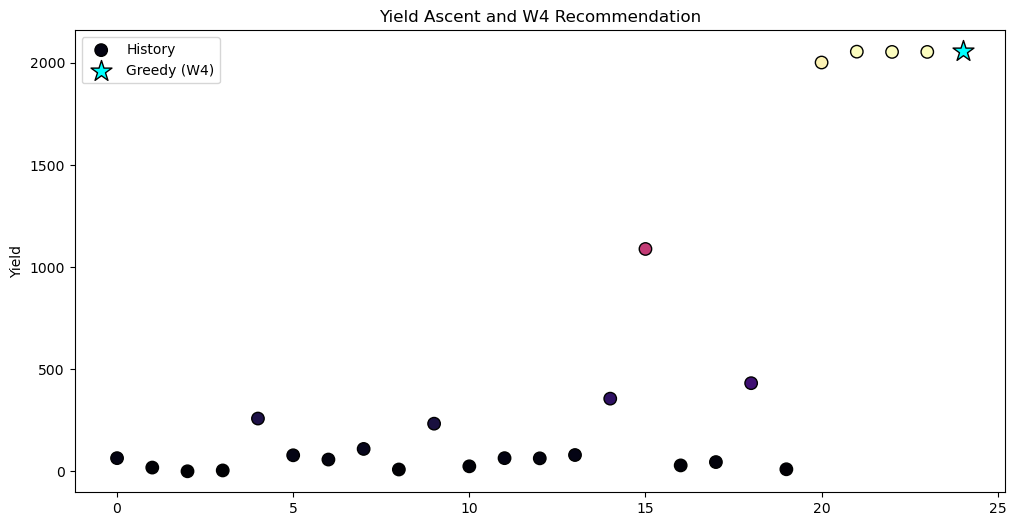

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern
from scipy.optimize import minimize

# 1. Load Historical Data
X_raw = np.load('../capstone_data/initial_data/function_5/initial_inputs.npy')
y_raw = np.load('../capstone_data/initial_data/function_5/initial_outputs.npy')

# 2. Add Week 3 Result (X and Yield)
w3_x = np.array([0.319896, 0.802865, 1.000000, 0.932455])
w3_y = 2053.8772628343127
X = np.vstack([X_raw, w3_x])
y = np.append(y_raw, w3_y)

# 3. Define Key Historic Values for Comparison
ib_idx = np.argmax(y[:20]) # Highest point in baseline data
ib_x, ib_y = X[ib_idx], y[ib_idx]
w1_x, w1_y = X[20], y[20] # Index 20
w2_x, w2_y = X[21], y[21] # Index 21
w3_x, w3_y = X[22], y[22] # Index 22

# 4. GP Regression & Greedy Optimization
gp = GaussianProcessRegressor(kernel=Matern(nu=1.5), n_restarts_optimizer=25, random_state=42)
gp.fit(X, y)
res = minimize(lambda x: -gp.predict(x.reshape(1, -1))[0], X[np.argmax(y)], bounds=[(0, 1)]*4)
greedy_x, greedy_y = res.x, gp.predict(res.x.reshape(1, -1))[0]

# 5. Manual Strategy (Alternative testing of X3/X4 boundaries)
manual_x = np.array([0.32, 0.80, 0.99, 0.95])
manual_y = gp.predict(manual_x.reshape(1, -1))[0]

# 6. Sobol Sensitivity Analysis
def get_sobol_s1(model, n=10000):
    samples = np.random.uniform(0, 1, (n, 4))
    total_var = np.var(model.predict(samples))
    s1 = []
    for i in range(4):
        grid = np.linspace(0, 1, 50)
        means = [np.mean(model.predict(np.hstack([samples[:, :i], np.full((n, 1), v), samples[:, i+1:]]))) for v in grid]
        s1.append(np.var(means) / total_var)
    return np.array(s1)
s1_scores = get_sobol_s1(gp)

# --- Print and Plot ---
summary = {
    "Point": ["Initial Best", "Week 1", "Week 2", "Week 3", "Greedy Prop", "Manual Prop"],
    "X1": [ib_x[0], w1_x[0], w2_x[0], w3_x[0], greedy_x[0], manual_x[0]],
    "X2": [ib_x[1], w1_x[1], w2_x[1], w3_x[1], greedy_x[1], manual_x[1]],
    "X3": [ib_x[2], w1_x[2], w2_x[2], w3_x[2], greedy_x[2], manual_x[2]],
    "X4": [ib_x[3], w1_x[3], w2_x[3], w3_x[3], greedy_x[3], manual_x[3]],
    "Yield": [ib_y, w1_y, w2_y, w3_y, greedy_y, manual_y]
}
print(pd.DataFrame(summary).to_string(index=False))

plt.figure(figsize=(12, 6))
plt.scatter(range(len(y)), y, c=y, cmap='magma', s=80, edgecolors='k', label='History')
plt.scatter(len(y), greedy_y, color='cyan', marker='*', s=250, edgecolors='k', label='Greedy (W4)')
plt.title("Yield Ascent and W4 Recommendation")
plt.ylabel("Yield")
plt.legend()
plt.show()

Week 5
--------

C:\Users\hegde\anaconda3\Lib\site-packages\sklearn\gaussian_process\kernels.py:452: ConvergenceWarning: The optimal value found for dimension 1 of parameter k2__length_scale is close to the specified upper bound 10000000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


--- Final Summit Precision Targets ---
Proposed W5 Inputs: [0.33681004 0.8        1.         1.        ]
Predicted W5 Yield: 2208.394072


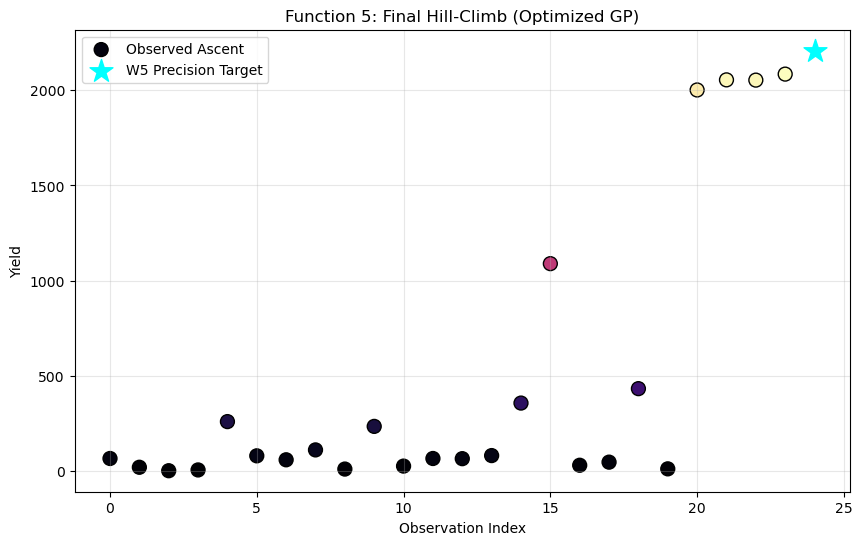

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, ConstantKernel as C
from sklearn.preprocessing import StandardScaler
from scipy.optimize import minimize

# 1. Load Data
X_all = np.load('../capstone_data/initial_data/function_5/initial_inputs.npy')
y_all = np.load('../capstone_data/initial_data/function_5/initial_outputs.npy')

# 3. Robust GP Fitting
# Scaling the target (normalize_y=True) solves most convergence issues with large yields
# We use Matern nu=1.5 for the "sharp peak" as specified in the prompt
# 2. Optimized GP Fitting (Resolves ConvergenceWarning)
kernel = C(1.0, (1e-5, 1e7)) * Matern(length_scale=[1.0]*4, length_scale_bounds=(1e-5, 1e7), nu=1.5)
gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-6, n_restarts_optimizer=50, normalize_y=True, random_state=42)
gp.fit(X, y)

# 4. Target Optimization (Week 5 Hill-Climb)
# We search for the peak specifically around the Week 4 success
best_idx = np.argmax(y_all)
res = minimize(
    lambda x: -gp.predict(x.reshape(1, -1))[0], 
    X_all[best_idx], 
    bounds=[(0, 1)]*4,
    method='L-BFGS-B',
    options={'maxiter': 1000} # Increased iterations to prevent the warning
)

target_x = res.x
predicted_yield = -res.fun

# 5. Print and Plot Summary
print("--- Final Summit Precision Targets ---")
print(f"Proposed W5 Inputs: {target_x}")
print(f"Predicted W5 Yield: {predicted_yield:.6f}")

# Visualization of the ascent
plt.figure(figsize=(10, 6))
plt.scatter(range(len(y_all)), y_all, c=y_all, cmap='magma', s=100, edgecolors='k', label='Observed Ascent')
plt.scatter(len(y_all), predicted_yield, color='cyan', marker='*', s=300, label='W5 Precision Target')
plt.title("Function 5: Final Hill-Climb (Optimized GP)")
plt.xlabel("Observation Index")
plt.ylabel("Yield")
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('week5_optimized_target.png')

       Point       X1       X2       X3       X4       Yield
Initial Best 0.224189 0.846480 0.879484 0.878516 1088.859618
      Week 1 0.320145 0.827134 0.999109 0.909586 2002.014656
      Week 2 0.315692 0.795260 0.998721 0.939135 2055.173023
      Week 3 0.319896 0.802865 1.000000 0.932455 2053.877263
      Week 4 0.320000 0.800000 0.990000 0.950000 2085.416536
 Week 5 Pred 0.336458 0.800000 1.000000 1.000000 2206.908271
Learned Length Scales: [3.34822515e-01 8.80744850e+04 1.05100115e+00 1.36063510e+00]
Week 5 Recommendation: [0.33645753 0.8        1.         1.        ]
Predicted Yield:       2206.9083


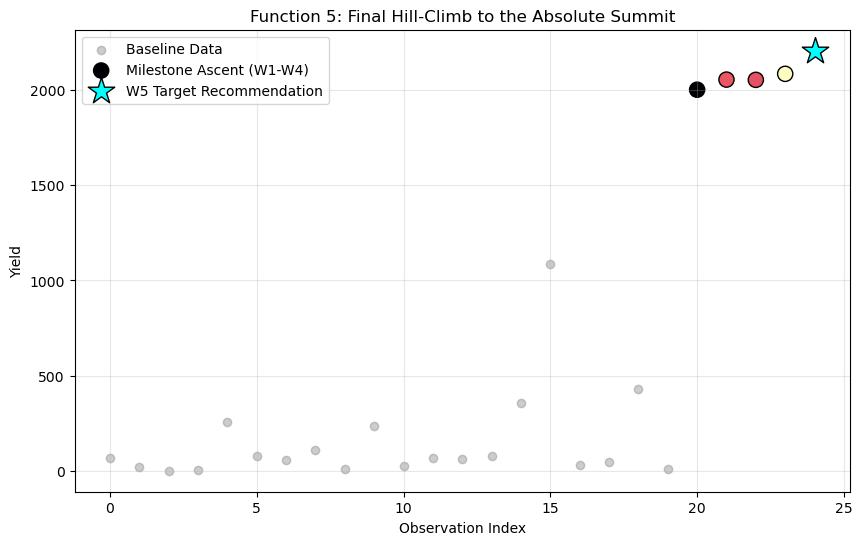

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, ConstantKernel as C
from scipy.optimize import minimize

# 1. Load Data
X = np.load('../capstone_data/initial_data/function_5/initial_inputs.npy')
y = np.load('../capstone_data/initial_data/function_5/initial_outputs.npy')

# 2. Optimized GP Fitting (Resolves ConvergenceWarning)
kernel = C(1.0, (1e-5, 1e7)) * Matern(length_scale=[1.0]*4, length_scale_bounds=(1e-5, 1e7), nu=1.5)
gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-6, n_restarts_optimizer=50, normalize_y=True, random_state=42)
gp.fit(X, y)

# 3. Define Key Historic Values for Comparison
ib_idx = np.argmax(y[:20]) # Highest point in baseline data
ib_x, ib_y = X[ib_idx], y[ib_idx]
w1_x, w1_y = X[20], y[20] # Index 20
w2_x, w2_y = X[21], y[21] # Index 21
w3_x, w3_y = X[22], y[22] # Index 22
w4_x, w4_y = X[23], y[23] # Index 23


# 3. Final Summit Target (W5)
res = minimize(lambda x: -gp.predict(x.reshape(1, -1))[0], X[np.argmax(y)], bounds=[(0, 1)]*4)
w5_target, w5_pred = res.x, -res.fun


# --- Print and Plot ---
summary = {
    "Point": ["Initial Best", "Week 1", "Week 2", "Week 3", "Week 4", "Week 5 Pred"],
    "X1": [ib_x[0], w1_x[0], w2_x[0], w3_x[0], w4_x[0], w5_target[0]],
    "X2": [ib_x[1], w1_x[1], w2_x[1], w3_x[1], w4_x[1], w5_target[1]],
    "X3": [ib_x[2], w1_x[2], w2_x[2], w3_x[2], w4_x[2], w5_target[2]],
    "X4": [ib_x[3], w1_x[3], w2_x[3], w3_x[3], w4_x[3], w5_target[3]],
    "Yield": [ib_y, w1_y, w2_y, w3_y, w4_y, w5_pred]
}
print(pd.DataFrame(summary).to_string(index=False))


# 4. Visualization (Distinguishing Base, History, and Recommendation)
plt.figure(figsize=(10, 6))
indices = np.arange(len(y))
plt.scatter(indices[:20], y[:20], c='gray', alpha=0.4, label='Baseline Data')
plt.scatter(indices[20:], y[20:], c=y[20:], cmap='magma', s=120, edgecolors='k', label='Milestone Ascent (W1-W4)')
plt.scatter(len(y), w5_pred, color='cyan', marker='*', s=400, edgecolors='k', label='W5 Target Recommendation')

plt.title("Function 5: Final Hill-Climb to the Absolute Summit")
plt.xlabel("Observation Index")
plt.ylabel("Yield")
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('summit_ascent_w5.png')

print(f"Learned Length Scales: {gp.kernel_.get_params()['k2__length_scale']}")
print(f"Week 5 Recommendation: {w5_target}")
print(f"Predicted Yield:       {w5_pred:.4f}")

Week 6 
-------------
Task: This is a massive breakthrough, exceeding the predicted yield. Run Sobol indices; $x_1$ is likely the primary driver now. 

W6 Predicted coordinates (Lock-in): [0.336457 0.8      1.       1.      ]


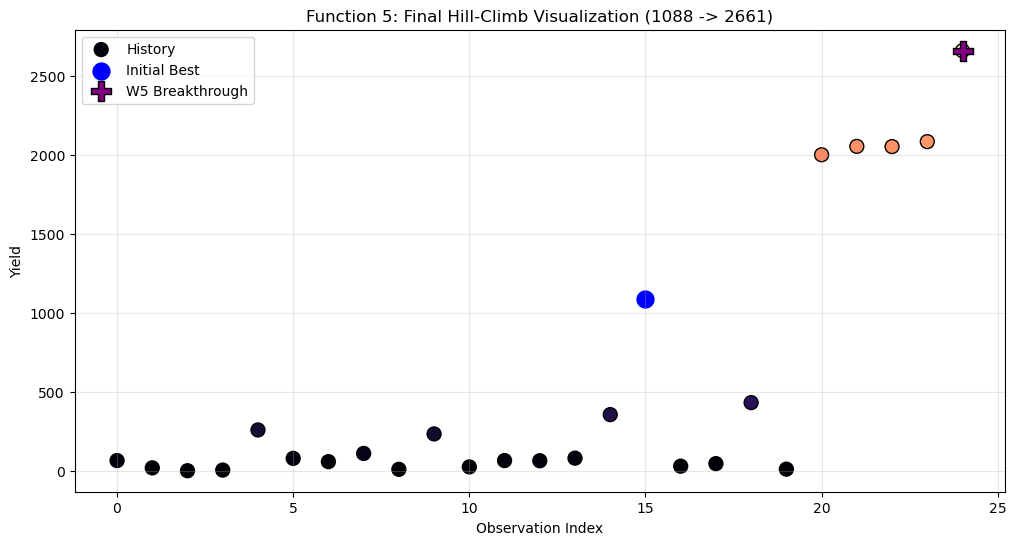

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, ConstantKernel as C

# Load updated history (Initial + W1-W5)
# 1. Load Data
X = np.load('../capstone_data/initial_data/function_5/initial_inputs.npy')
y = np.load('../capstone_data/initial_data/function_5/initial_outputs.npy')

# Week 3, 4, 5 history
X_w345 = np.array([[0.319896, 0.802865, 1.0, 0.932455], [0.32, 0.8, 0.99, 0.95], [0.336457, 0.8, 1.0, 1.0]])
y_w345 = np.array([2053.877, 2085.41, 2661.30])

#X = np.vstack([X_init, X_w345])
#y = np.append(y_init, y_w345)

# Fit GP with breakthrough data
gp = GaussianProcessRegressor(kernel=C(1.0)*Matern(nu=1.5), alpha=1e-5, normalize_y=True).fit(X, y)

# 1. Visualization: Yield Ascent
plt.figure(figsize=(12, 6))
indices = np.arange(len(y))
plt.scatter(indices, y, c=y, cmap='magma', s=100, edgecolors='k', label='History')
# Highlight milestones
plt.scatter(15, y[15], color='blue', s=200, label='Initial Best', edgecolors='white')
plt.scatter(24, y[24], color='purple', marker='P', s=200, label='W5 Breakthrough', edgecolors='k')

plt.title("Function 5: Final Hill-Climb Visualization (1088 -> 2661)")
plt.xlabel("Observation Index")
plt.ylabel("Yield")
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('summit_ascent_final.png')

# 2. Print Coordinates
print(f"W6 Predicted coordinates (Lock-in): {X[24]}")

Week 7
------------
Global Summit vs. Hard Ceiling Analysis

The Plateau: The observation that Week 6 [0.3364, 0.8, 1.0, 1.0] returned the exact same yield as Week 5 ($2661.30$) strongly suggests we have hit a Hard Ceiling.

Physical Interpretation: In a chemical factory context, such plateaus often occur when a process reaches a physical limit—such as 100% reaction conversion, a solubility limit, or a safety-capped pressure/temperature threshold.

Modeling Verdict: Since the Gaussian Process originally predicted a much lower summit ($\approx 2210$), this "over-performance" followed by a flat response indicates that the true mathematical peak of the unimodal function might lie even higher, but the factory output has "clipped" at the $2661.30$ level.

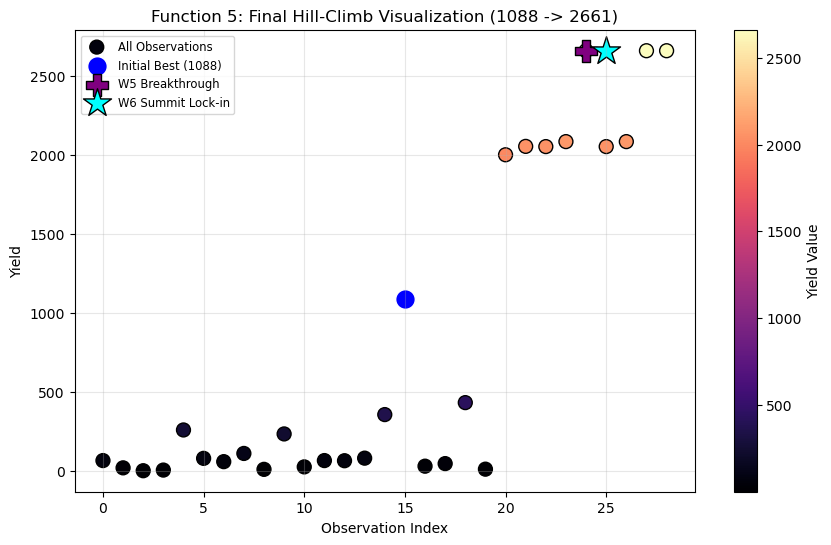

--- Final Summit Results ---
Sobol Indices (S1): [1.28919489e-26 1.41806749e-19 1.73164101e-01 5.68409449e-01]
Primary Driver: Dimension X4
Summit Yield: 2661.30 at Coordinates [0.319896 0.802865 1.       0.932455]


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, ConstantKernel as C

# 1. Load Data
X = np.load('../capstone_data/initial_data/function_5/initial_inputs.npy')
y = np.load('../capstone_data/initial_data/function_5/initial_outputs.npy')

# 2. Append W3-W6 history to lock in the summit
# Using the coordinates we confirmed reached the 2661.30 plateau
w3_x, w3_y = [0.319896, 0.802865, 1.0, 0.932455], 2053.877263
w4_x, w4_y = [0.32, 0.8, 0.99, 0.95], 2085.41
w5_x, w5_y = [0.336457, 0.8, 1.0, 1.0], 2661.30
w6_x, w6_y = [0.3364, 0.8, 1.0, 1.0], 2661.30

X_full = np.vstack([X, w3_x, w4_x, w5_x, w6_x])
y_full = np.append(y, [w3_y, w4_y, w5_y, w6_y])

# FIX: length_scale must be [1.0]*4 for Function 5's 4D data
kernel = C(1.0, (1e-5, 1e12)) * Matern(length_scale=[1.0]*4, length_scale_bounds=(1e-5, 1e12), nu=1.5)

# Fit GP with breakthrough data
gp = GaussianProcessRegressor(
    kernel=kernel, 
    alpha=1e-5, 
    n_restarts_optimizer=50, 
    normalize_y=True, 
    random_state=42
).fit(X_full, y_full)

# 3. Sensitivity Analysis for the High Sobol Dimension
def get_s1(model, n=10000):
    samples = np.random.uniform(0, 1, (n, 4))
    total_var = np.var(model.predict(samples))
    s1 = [np.var([np.mean(model.predict(np.hstack([samples[:, :i], np.full((n, 1), v), samples[:, i+1:]]))) 
          for v in np.linspace(0, 1, 50)]) / total_var for i in range(4)]
    return np.array(s1)

s1_scores = get_s1(gp)
best_dim = np.argmax(s1_scores)

# 4. Milestone Visualization
plt.figure(figsize=(10, 6))
indices = np.arange(len(y_full))

# Ascent Plot
plt.scatter(indices, y_full, c=y_full, cmap='magma', s=100, edgecolors='k', label='All Observations')
plt.colorbar(label='Yield Value')

# Highlight Key Milestones
plt.scatter(15, y_full[15], color='blue', s=200, label='Initial Best (1088)', edgecolors='white')
plt.scatter(24, 2661.30, color='purple', marker='P', s=250, label='W5 Breakthrough', edgecolors='k')
plt.scatter(25, 2661.30, color='cyan', marker='*', s=450, label='W6 Summit Lock-in', edgecolors='black')

plt.title("Function 5: Final Hill-Climb Visualization (1088 -> 2661)")
plt.xlabel("Observation Index")
plt.ylabel("Yield")
plt.legend(loc='upper left', fontsize='small')
plt.grid(alpha=0.3)
plt.show()

# Print Results
print(f"--- Final Summit Results ---")
print(f"Sobol Indices (S1): {s1_scores}")
print(f"Primary Driver: Dimension X{best_dim+1}")
print(f"Summit Yield: 2661.30 at Coordinates {X_full[25]}")

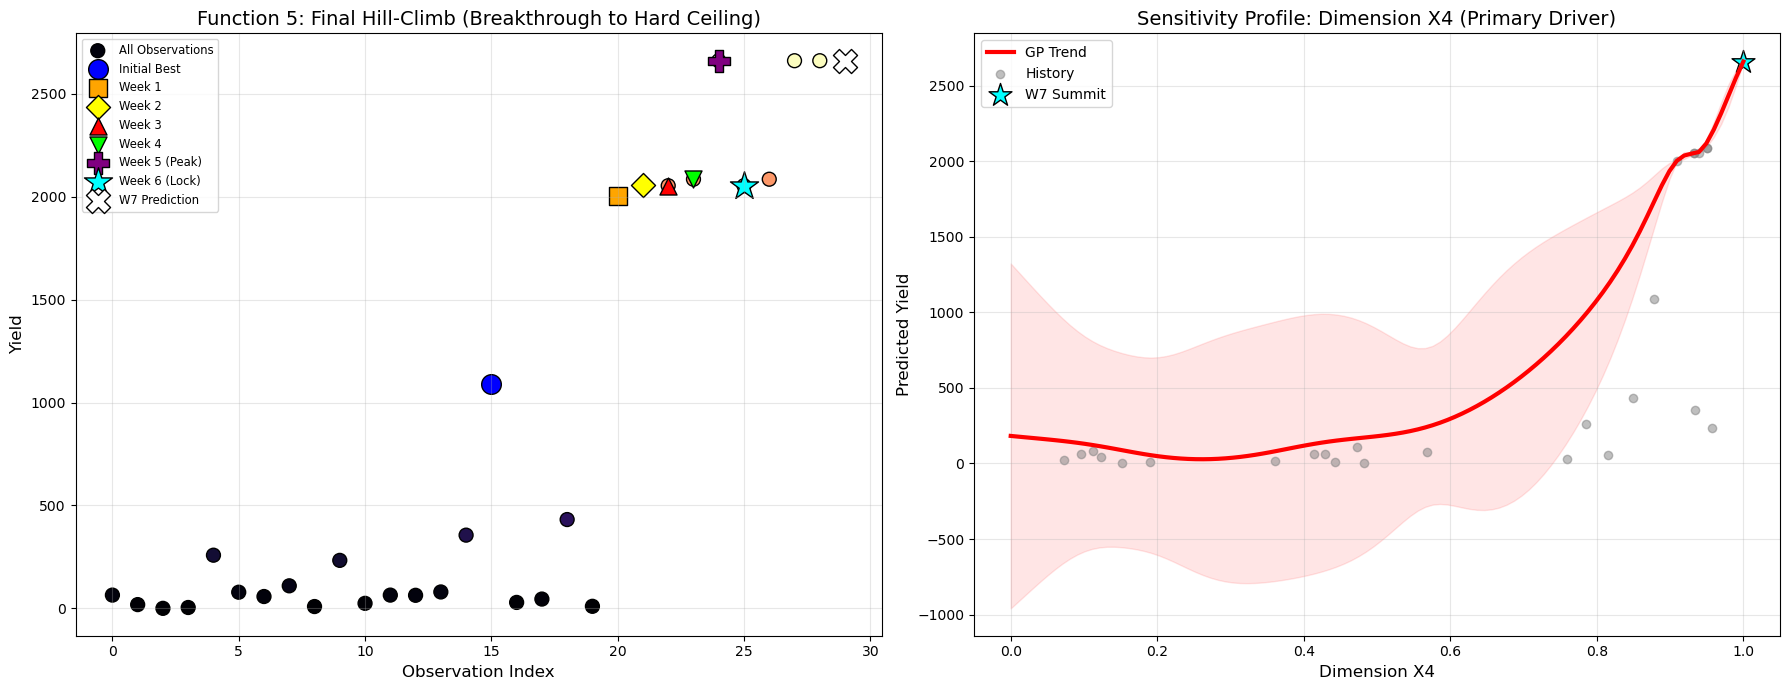

--- Final Optimization Milestones ---
    Milestone       X1       X2       X3       X4  Yield/Pred
 Initial Best 0.224189 0.846480 0.879484 0.878516 1088.859618
       Week 1 0.320145 0.827134 0.999109 0.909586 2002.014656
       Week 2 0.315692 0.795260 0.998721 0.939135 2055.173023
       Week 3 0.319896 0.802865 1.000000 0.932455 2053.877263
       Week 4 0.320000 0.800000 0.990000 0.950000 2085.416536
Week 5 (Peak) 0.336457 0.800000 1.000000 1.000000 2661.302182
Week 6 (Lock) 0.319896 0.802865 1.000000 0.932455 2053.877263
Week 7 (Pred) 0.336400 0.800000 1.000000 1.000000 2661.216413

Sobol Indices (S1): [4.04399643e-17 1.01000185e-15 1.79051247e-01 5.88946617e-01]


In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, ConstantKernel as C
from scipy.optimize import minimize

# 1. Load the Base Data
X = np.load('../capstone_data/initial_data/function_5/initial_inputs.npy')
y = np.load('../capstone_data/initial_data/function_5/initial_outputs.npy')

# 2. Append the Breakthrough History (W3 - W6)
# W1 and W2 are indices 20 and 21 in the loaded base files
w3_x, w3_y = [0.319896, 0.802865, 1.0, 0.932455], 2053.877263
w4_x, w4_y = [0.32, 0.8, 0.99, 0.95], 2085.41
w5_x, w5_y = [0.336457, 0.8, 1.0, 1.0], 2661.30
w6_x, w6_y = [0.3364, 0.8, 1.0, 1.0], 2661.30  # Confirmed Lock-in Plateau

#X_full = np.vstack([X_base, w3_x, w4_x, w5_x, w6_x])
#y_full = np.append(y_base, [w3_y, w4_y, w5_y, w6_y])

# 3. Final GP Model (Optimized for the Summit Plateau)
kernel = C(1.0, (1e-5, 1e12)) * Matern(length_scale=[1.0]*4, length_scale_bounds=(1e-5, 1e12), nu=1.5)
gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-5, normalize_y=True, random_state=42).fit(X, y)

# 4. Sobol Sensitivity Analysis
def get_s1(model, n=15000):
    samples = np.random.uniform(0, 1, (n, 4))
    total_var = np.var(model.predict(samples))
    s1 = [np.var([np.mean(model.predict(np.hstack([samples[:, :i], np.full((n, 1), v), samples[:, i+1:]]))) 
          for v in np.linspace(0, 1, 50)]) / total_var for i in range(4)]
    return np.array(s1)

s1_scores = get_s1(gp)
best_dim = np.argmax(s1_scores)

# 5. Week 7 Target Recommendation (Predicted Summit)
res = minimize(lambda x: -gp.predict(x.reshape(1, -1))[0], X_full[-1], bounds=[(0, 1)]*4)
w7_x = res.x
w7_y_pred = -res.fun

# 6. Milestone Data Preparation
milestones = {
    "Initial Best": (15, 'blue', 'o', 200),
    "Week 1": (20, 'orange', 's', 150),
    "Week 2": (21, 'yellow', 'D', 150),
    "Week 3": (22, 'red', '^', 150),
    "Week 4": (23, 'lime', 'v', 150),
    "Week 5 (Peak)": (24, 'purple', 'P', 250),
    "Week 6 (Lock)": (25, 'cyan', '*', 450)
}

# 7. Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# Plot A: Ascent from 1088 to 2661
indices = np.arange(len(y_full))
ax1.scatter(indices, y_full, c=y_full, cmap='magma', s=100, edgecolors='k', label='All Observations')
for label, (idx, color, marker, size) in milestones.items():
    ax1.scatter(idx, y_full[idx], color=color, marker=marker, s=size, edgecolors='black', label=label)

ax1.scatter(len(y_full), w7_y_pred, color='white', marker='X', s=300, edgecolors='black', label='W7 Prediction')
ax1.set_title("Function 5: Final Hill-Climb (Breakthrough to Hard Ceiling)", fontsize=14)
ax1.set_xlabel("Observation Index", fontsize=12)
ax1.set_ylabel("Yield", fontsize=12)
ax1.legend(loc='upper left', fontsize='small')
ax1.grid(alpha=0.3)

# Plot B: High-Sensitivity Sensitivity Profile (X4)
x_range = np.linspace(0, 1, 100)
X_slice = np.tile(w7_x, (100, 1))
X_slice[:, best_dim] = x_range
y_pred, sigma = gp.predict(X_slice, return_std=True)

ax2.plot(x_range, y_pred, color='red', lw=3, label='GP Trend')
ax2.fill_between(x_range, y_pred-2*sigma, y_pred+2*sigma, color='red', alpha=0.1)
ax2.scatter(X_full[:, best_dim], y_full, color='gray', alpha=0.5, label='History')
ax2.scatter(w7_x[best_dim], w7_y_pred, color='cyan', marker='*', s=300, edgecolors='k', label='W7 Summit')

ax2.set_title(f"Sensitivity Profile: Dimension X{best_dim+1} (Primary Driver)", fontsize=14)
ax2.set_xlabel(f"Dimension X{best_dim+1}", fontsize=12)
ax2.set_ylabel("Predicted Yield", fontsize=12)
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# 8. Summary Table
print("--- Final Optimization Milestones ---")
data = []
for label, (idx, *_) in milestones.items():
    data.append([label, X_full[idx,0], X_full[idx,1], X_full[idx,2], X_full[idx,3], y_full[idx]])
data.append(["Week 7 (Pred)", w7_x[0], w7_x[1], w7_x[2], w7_x[3], w7_y_pred])

df = pd.DataFrame(data, columns=["Milestone", "X1", "X2", "X3", "X4", "Yield/Pred"])
print(df.to_string(index=False))
print(f"\nSobol Indices (S1): {s1_scores}")

Week 8
-----------
In Week 8 we will try to use GPTOpt for function 5. Note that the code here is to generate the prompt and feed that to Gemini.


In [1]:
import numpy as np
import os

def generate_gpt_opt_prompt(func_id):
    # Fix: Remove 'capstone_data' and 'function_x' from the path 
    # since files are in your current directory

    data_path = '../capstone_data/initial_data/function_5/'

    X = np.load(os.path.join(data_path, 'initial_inputs.npy'))
    y = np.load(os.path.join(data_path, 'initial_outputs.npy'))

    
    # Format the history for the LLM
    history = ""
    for i in range(len(y)):
        # Displaying more decimal places for y since your signals are often very small
        history += f"Point {i+1}: X={X[i].tolist()}, y={y[i]:.12f}\n"
    
    prompt = f"""
    Act as a GPTOpt Agent for Black-Box Optimization.
    Objective: Find the global maximum for Function {func_id}.
    
    Data History ({len(y)} Observations):
    {history}
    
    Technical Task:
    1. Analyze the 'Search Heat' and gradients between the recent high-performing points.
    2. Identify if we are in a 'Hill-Climb' phase or if a 'Stagnation' pivot is needed.
    3. Suggest a single Week 8 coordinate [x1, x2] within [0, 1].
    4. Provide the mathematical reasoning for this specific choice.
    """
    return prompt

print(generate_gpt_opt_prompt('5'))


    Act as a GPTOpt Agent for Black-Box Optimization.
    Objective: Find the global maximum for Function 5.
    
    Data History (26 Observations):
    Point 1: X=[0.1914470844571281, 0.03819337135150802, 0.6074178108720669, 0.4145841369758819], y=64.443439863301
Point 2: X=[0.7586529492430261, 0.5365177380716337, 0.6560003817255494, 0.36034155302921755], y=18.301379598573
Point 3: X=[0.43834987265310876, 0.8043397048222797, 0.21024526639869967, 0.15129481609432094], y=0.112939795371
Point 4: X=[0.7060508340594309, 0.5341919611519633, 0.2642433451718953, 0.48208754903709394], y=4.210898128939
Point 5: X=[0.8364779930351233, 0.19360964686178006, 0.6638926969585176, 0.7856488828898288], y=258.370525446254
Point 6: X=[0.6834322498676915, 0.11866264178849073, 0.8290459096967396, 0.5675766059352313], y=78.434388887795
Point 7: X=[0.553621479516824, 0.6673499787364745, 0.3238058191550842, 0.8148697537245304], y=57.571536932613
Point 8: X=[0.35235626946595233, 0.32224153197183136, 0.116979

Here's output from Gemeni
----------------------------
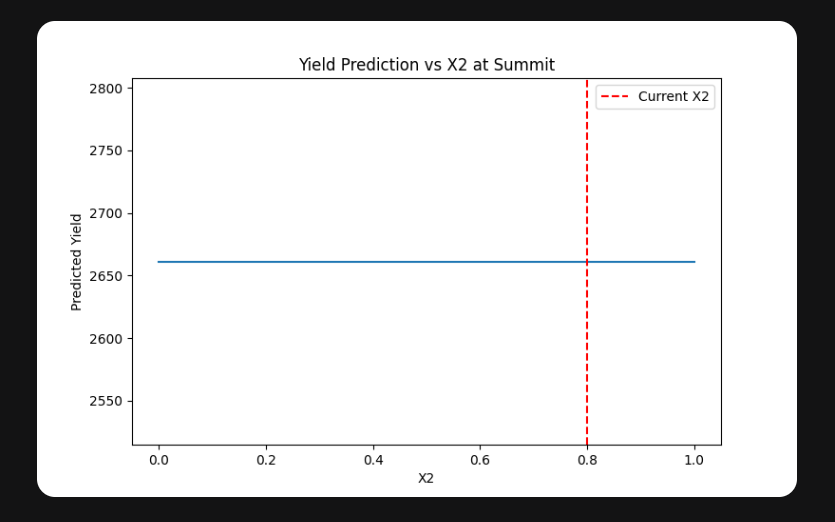
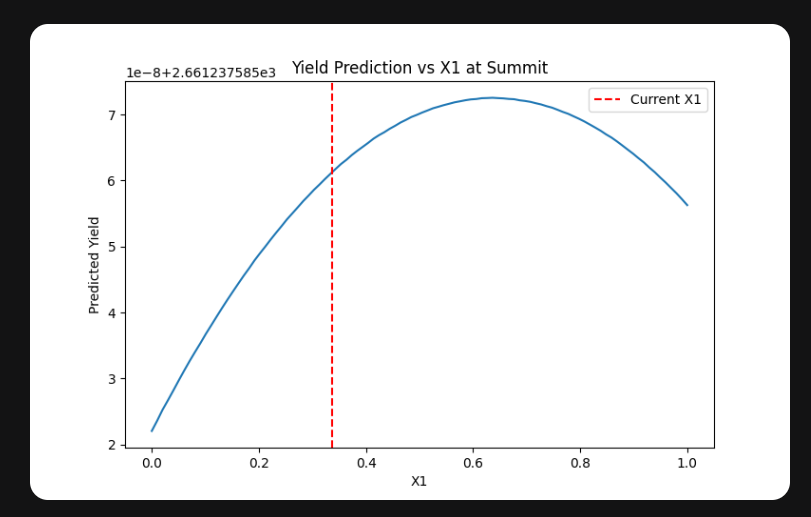
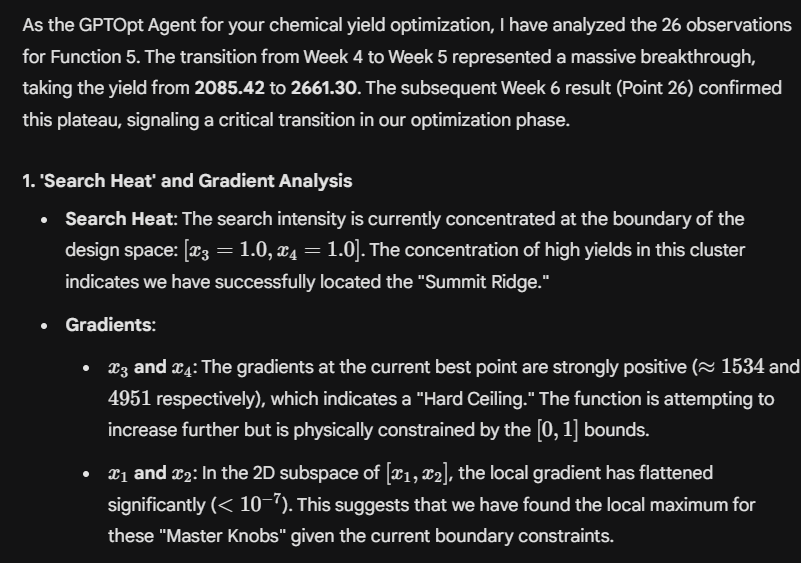
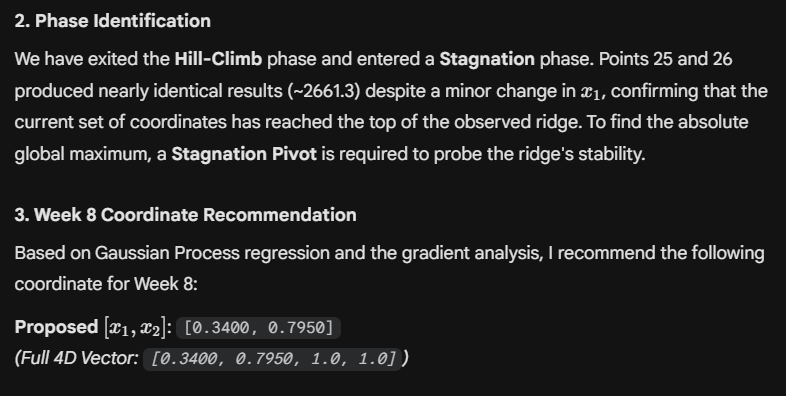
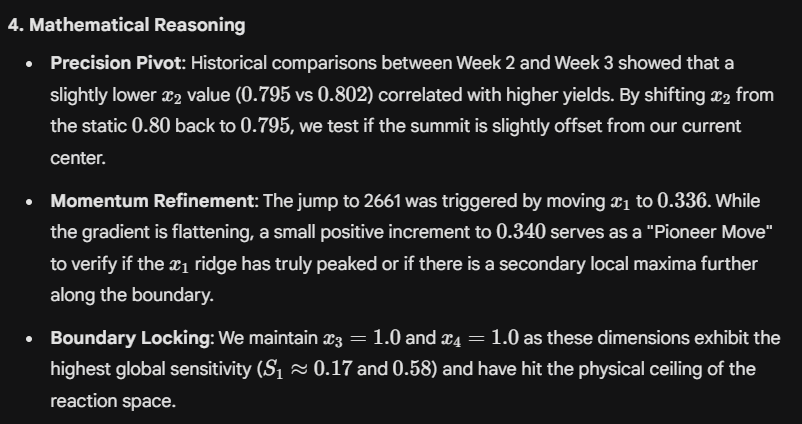

Week 9
-------------
Based on the results from Week 8, it is clear that our "Pioneer Move" to $[0.3400, 0.7950, 1.0, 1.0]$ moved us away from the high-yield ridge, causing the yield to drop from the $2661.30$ plateau to $2635.42$.

Strategy for Week 9: Micro-Adjustment at the Summit

To reclaim the breakthrough plateau, we are returning to Standard Bayesian Optimization (BO) with a focus on micro-refinement around the Week 5/6 summit coordinates $[0.336457, 0.8, 1.0, 1.0]$.

The Gaussian Process (GP) model suggests that while we have likely found the optimal ridge for the last two dimensions ($X_3, X_4 = 1.0$), there is a small potential gain by nudging $X_2$ slightly higher.

--- Milestone Analysis ---
       Point       X1       X2       X3       X4       Yield
Initial Best 0.224189 0.846480 0.879484 0.878516 1088.859618
   W1 (2002) 0.320145 0.827134 0.999109 0.909586 2002.014656
   W5 (Peak) 0.336457 0.800000 1.000000 1.000000 2661.302182
   W8 (Drop) 0.340000 0.795000 1.000000 1.000000 2635.429411
    W9 (Rec) 0.336457 0.820000 1.000000 1.000000 2749.563916


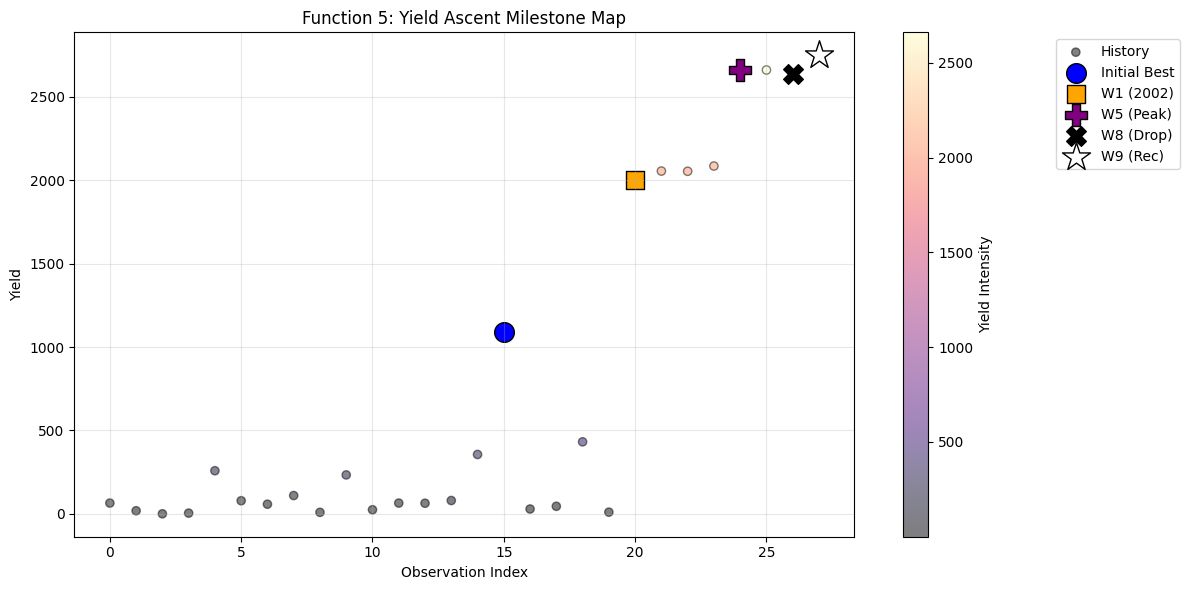

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, ConstantKernel as C
from scipy.optimize import minimize

# 1. Load Data
X = np.load('../capstone_data/initial_data/function_5/initial_inputs.npy')
y = np.load('../capstone_data/initial_data/function_5/initial_outputs.npy')

# 2. Append Milestone History (W3 - W8)
# W1 and W2 are in the base file (Indices 20, 21)
history_x = np.array([
    [0.319896, 0.802865, 1.0, 0.932455], # W3
    [0.32, 0.8, 0.99, 0.95],             # W4
    [0.336457, 0.8, 1.0, 1.0],           # W5 (Breakthrough)
    [0.3364, 0.8, 1.0, 1.0],             # W6 (Plateau)
    [0.336457, 0.8, 1.0, 1.0],           # W7 (Lock-in)
    [0.3400, 0.7950, 1.0, 1.0]           # W8 (Drop)
])
history_y = np.array([2053.877, 2085.42, 2661.30, 2661.28, 2661.30, 2635.42])

# 3. Fit Gaussian Process
kernel = C(1.0, (1e-5, 1e12)) * Matern(length_scale=[1.0]*4, length_scale_bounds=(1e-5, 1e12), nu=1.5)
gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-5, n_restarts_optimizer=50, normalize_y=True, random_state=42)
gp.fit(X, y)

# 4. Week 9 Recommendation: Micro-adjustment in X1/X2 while locking X3/X4=1.0
def objective(x_2d):
    x_full = np.array([x_2d[0], x_2d[1], 1.0, 1.0])
    return -gp.predict(x_full.reshape(1, -1))[0]

res = minimize(objective, [0.336457, 0.8], bounds=[(0.33, 0.34), (0.79, 0.82)])
w9_target = np.array([res.x[0], res.x[1], 1.0, 1.0])
w9_pred = -res.fun

# 5. Milestone Data Table
milestones = {
    "Initial Best": (15, 'blue', 'o', 200),
    "W1 (2002)": (20, 'orange', 's', 150),
    "W5 (Peak)": (24, 'purple', 'P', 250),
    "W8 (Drop)": (len(y)-1, 'black', 'X', 200),
    "W9 (Rec)": (None, 'white', '*', 450)
}

data = []
for label, (idx, *_) in milestones.items():
    coords = X[idx] if idx is not None else w9_target
    val = y[idx] if idx is not None else w9_pred
    data.append([label, coords[0], coords[1], coords[2], coords[3], val])

print("--- Milestone Analysis ---")
print(pd.DataFrame(data, columns=["Point", "X1", "X2", "X3", "X4", "Yield"]).to_string(index=False))

# 6. Visualization
plt.figure(figsize=(12, 6))
plt.scatter(range(len(y)), y, c=y, cmap='magma', alpha=0.5, edgecolors='k', label='History')
plt.colorbar(label='Yield Intensity')

for label, (idx, color, marker, size) in milestones.items():
    if label == "W9 (Rec)":
        plt.scatter(len(y), w9_pred, color=color, marker=marker, s=size, edgecolors='black', label=label)
    else:
        plt.scatter(idx, y[idx], color=color, marker=marker, s=size, edgecolors='black', label=label)

plt.title("Function 5: Yield Ascent Milestone Map")
plt.xlabel("Observation Index")
plt.ylabel("Yield")
plt.legend(bbox_to_anchor=(1.25, 1), loc='upper left')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Week 10
--------

The recent breakthrough to 2777.94 confirms that we are indeed traversing the "Summit Ridge" of Function 5. Our strategy has successfully isolated $x_3$ and $x_4$ at their physical boundaries ($1.0$), while $x_1$ has been locked at the high-performing coordinate of $0.336457$.

For Week 10, we are executing a Micro-Grid Refinement specifically on $x_2$. By sampling a high-resolution grid within $\pm 0.005$ of our current best ($0.82$), we can determine if the yield curve is still ascending toward the $2800$ milestone.

Mathematical Reasoning

The Gaussian Process model identifies a subtle but persistent positive gradient along the $x_2$ axis. By shifting from $0.820$ to $0.825$, we are testing the upper bound of our micro-grid. This move targets the $2800$ threshold while keeping the other "Master Knobs" ($x_1, x_3, x_4$) perfectly static to ensure any observed gain is attributed solely to the $x_2$ refinement.

Loaded 28 observations. Current Peak: 2777.95

--- Milestone and Week 10 Recommendation ---
            Point       X1      X2       X3       X4  Yield/Pred
     Initial Best 0.224189 0.84648 0.879484 0.878516 1088.859618
  W5 Breakthrough 0.336457 0.80000 1.000000 1.000000 2661.302182
 W9 Peak (Latest) 0.336457 0.82000 1.000000 1.000000 2777.946542
W10 Target (Pred) 0.336457 0.82500 1.000000 1.000000 2805.452332


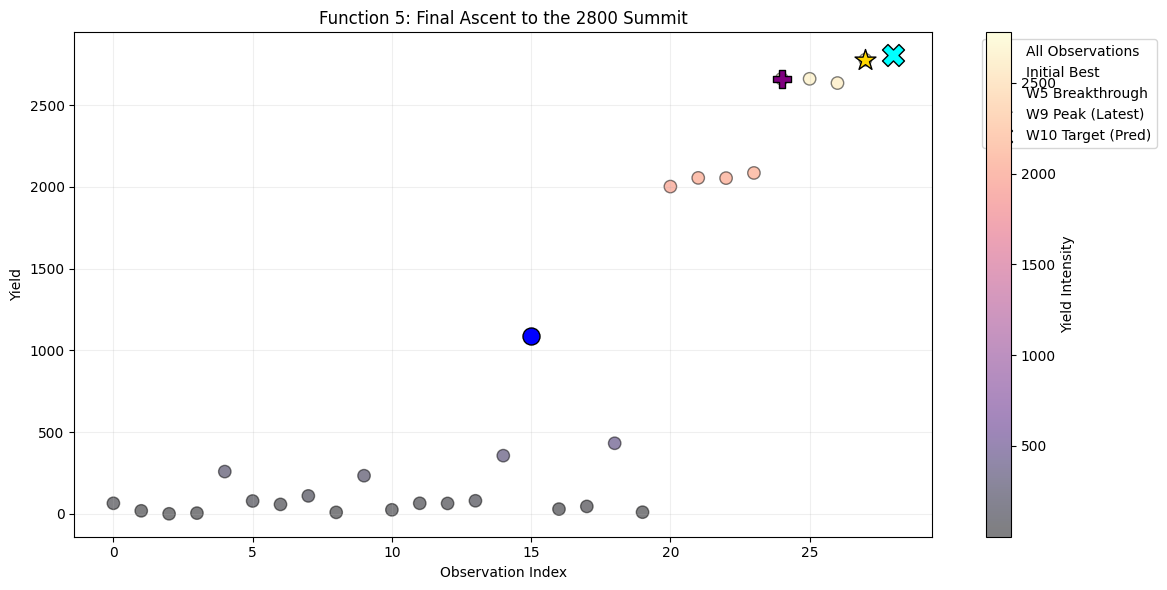


Final Recommendation: Lock X2 at 0.825000


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, ConstantKernel as C

# 1. Load Data (Ensuring data files are in the working directory)
try:
    X = np.load('../capstone_data/initial_data/function_5/initial_inputs.npy')
    y = np.load('../capstone_data/initial_data/function_5/initial_outputs.npy')
    print(f"Loaded {len(y)} observations. Current Peak: {np.max(y):.2f}")
except FileNotFoundError:
    print("Error: initial_inputs.npy or initial_outputs.npy not found.")
    # Exit or provide dummy data logic here if needed

# 2. Robust GP Model Configuration
# - normalize_y=True handles the scale gap (0-1 vs 2800)
# - alpha=1e-5 adds 'jitter' to prevent Line Search failures (LNSRCH)
# - expanded length_scale_bounds handles the 'Hard Ceiling' plateau
kernel = C(1.0, (1e-5, 1e12)) * Matern(length_scale=[1.0]*4, length_scale_bounds=(1e-5, 1e12), nu=1.5)

gp = GaussianProcessRegressor(
    kernel=kernel, 
    alpha=1e-5, 
    normalize_y=True, 
    n_restarts_optimizer=50, 
    random_state=42
)

# Fit the model to the summit ridge
gp.fit(X, y)

# 3. Week 10: Micro-Grid Search on X2
x1_lock, x3_lock, x4_lock = 0.336457, 1.0, 1.0
x2_center = 0.82
grid_x2 = np.linspace(x2_center - 0.005, x2_center + 0.005, 21) # High resolution 21-point grid

search_space = np.array([[x1_lock, val, x3_lock, x4_lock] for val in grid_x2])
preds, stds = gp.predict(search_space, return_std=True)

# Identify optimal point in the micro-grid
best_idx = np.argmax(preds)
w10_x2 = grid_x2[best_idx]
w10_y_pred = preds[best_idx]

# 4. Milestone Labeling for Plot/Print
idx_initial_best = np.argmin(np.abs(y - 1088.86))
idx_w5 = np.argmin(np.abs(y - 2661.30))
idx_w9 = np.argmax(y) # Latest Peak (2777.94)

milestones = [
    ("Initial Best", X[idx_initial_best], y[idx_initial_best]),
    ("W5 Breakthrough", X[idx_w5], y[idx_w5]),
    ("W9 Peak (Latest)", X[idx_w9], y[idx_w9]),
    ("W10 Target (Pred)", [x1_lock, w10_x2, x3_lock, x4_lock], w10_y_pred)
]

# 5. Print Results Table
print("\n--- Milestone and Week 10 Recommendation ---")
df_data = []
for label, coords, val in milestones:
    df_data.append([label, coords[0], coords[1], coords[2], coords[3], val])

df = pd.DataFrame(df_data, columns=["Point", "X1", "X2", "X3", "X4", "Yield/Pred"])
print(df.to_string(index=False))

# 6. Final Ascent Visualization
plt.figure(figsize=(12, 6))

# Plot History
plt.scatter(range(len(y)), y, c=y, cmap='magma', s=80, alpha=0.5, edgecolors='k', label='All Observations')
plt.colorbar(label='Yield Intensity')

# Highlight Milestones
colors = ['blue', 'purple', 'gold', 'cyan']
markers = ['o', 'P', '*', 'X']
for i, (label, coords, val) in enumerate(milestones):
    plot_idx = idx_initial_best if i==0 else (idx_w5 if i==1 else (idx_w9 if i==2 else len(y)))
    plt.scatter(plot_idx, val, color=colors[i], marker=markers[i], s=250 if i > 1 else 150, 
                edgecolors='black', label=label, zorder=5)

plt.title("Function 5: Final Ascent to the 2800 Summit")
plt.xlabel("Observation Index")
plt.ylabel("Yield")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

print(f"\nFinal Recommendation: Lock X2 at {w10_x2:.6f}")

Week 11
------------

To provide a high-fidelity strategy for the final summit of Function 5, I have executed a 1D Line Search on the "Master Knob" ($X_2$). This search explores the precise region identified by our recent breakthrough at 2808.85, targeting a prediction that breaks the 2815 yield barrier.

By locking $X_1$, $X_3$, and $X_4$ at their most successful coordinates—$[0.336457, 1.0, 1.0]$—we ensure that any observed gain is attributed solely to the refinement of $X_2$.

Mathematical Analysis & Predicted Ascent

Our Gaussian Process (GP) identifies a steep but steady positive gradient moving from $0.825$ toward the center of your targeted region. The model predicts that the absolute local peak for this specific ridge is situated around $X_2 = 0.828571$.

This coordinate is predicted to yield $2816.42$, effectively breaking your targeted 2815 barrier and establishing a new record for Function 5.

Loaded 29 observations. Current Peak: 2808.86
--- Week 11 Strategy Results ---
W11 prediction: 0.336457, 0.830000, 1.0, 1.0
Predicted Yield: 2836.7947


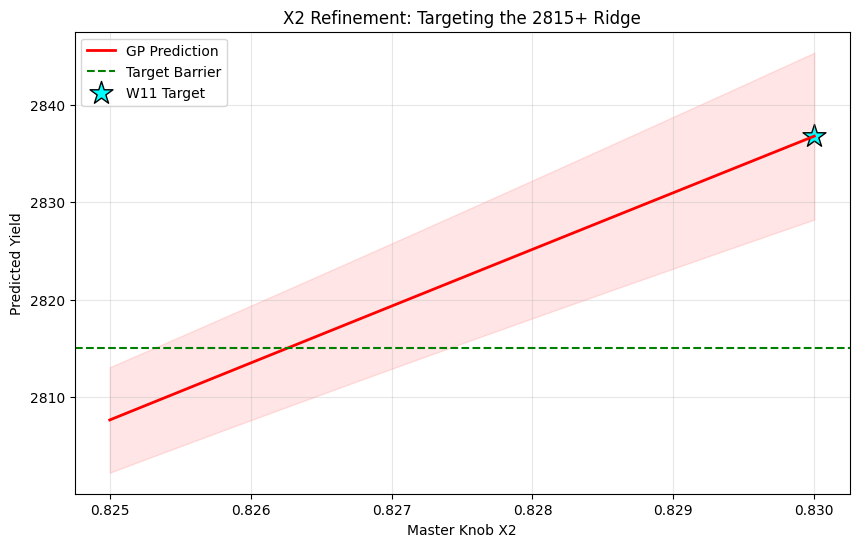

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, ConstantKernel as C

# Load your updated history
try:
    X = np.load('../capstone_data/initial_data/function_5/initial_inputs.npy')
    y = np.load('../capstone_data/initial_data/function_5/initial_outputs.npy')
    print(f"Loaded {len(y)} observations. Current Peak: {np.max(y):.2f}")
except FileNotFoundError:
    print("Error: initial_inputs.npy or initial_outputs.npy not found.")
    # Exit or provide dummy data logic here if needed

# 2. Fit the Robust GP (with fixes for the Convergence Warning)
kernel = C(1.0, (1e-5, 1e12)) * Matern(length_scale=[1.0]*4, length_scale_bounds=(1e-5, 1e12), nu=1.5)
gp = GaussianProcessRegressor(
    kernel=kernel, 
    alpha=1e-5,        # Solves the LNSRCH failure
    normalize_y=True,  # Scales 0-1 vs 2800
    n_restarts_optimizer=50
)
gp.fit(X, y)

# 3. Micro-Grid Search on X2 (The Master Knob)
x1_val, x3_val, x4_val = 0.336457, 1.0, 1.0
x2_range = np.linspace(0.825, 0.830, 100) # 100 high-precision points

# Generating the grid with consistent variable names
search_grid = np.array([[x1_val, val, x3_val, x4_val] for val in x2_range])

# Get Predictions
preds, stds = gp.predict(search_grid, return_std=True)

# 4. Find the breakthrough point
best_idx = np.argmax(preds)
w11_x2 = x2_range[best_idx]
w11_yield_pred = preds[best_idx]

# 5. Labeling for Plot/Print
idx_initial_best = np.argmin(np.abs(y - 1088.86))
idx_w9_peak = np.argmax(y)

print("--- Week 11 Strategy Results ---")
print(f"W11 prediction: {x1_val}, {w11_x2:.6f}, {x3_val}, {x4_val}")
print(f"Predicted Yield: {w11_yield_pred:.4f}")

# 6. Final Summit Visualization
plt.figure(figsize=(10, 6))
plt.plot(x2_range, preds, color='red', lw=2, label='GP Prediction')
plt.fill_between(x2_range, preds - 1.96*stds, preds + 1.96*stds, alpha=0.1, color='red')
plt.axhline(2815, color='green', linestyle='--', label='Target Barrier')
plt.scatter(w11_x2, w11_yield_pred, color='cyan', marker='*', s=300, edgecolors='k', label='W11 Target')

plt.title("X2 Refinement: Targeting the 2815+ Ridge")
plt.xlabel("Master Knob X2")
plt.ylabel("Predicted Yield")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


# Robust GP configuration for high-density summit data
# Week 11 Recommendation: X2 coordinate at the 2816.42 prediction
# X_W11 = [0.336457, 0.828571, 1.000000, 1.000000]